
# Fig. 3 수식 유도 + 플롯 노트북

논문 Fig. 3의 주제는 **distance-dependent neighboring NMDA current가 excitatory current stability를 어떻게 바꾸는가**이다.

이 노트북은 논문 전체 Brian2/Fortran full reproduction이 아니라, 발표에서 수식을 설명하기 위한 **derivation-first toy notebook**이다. 목표는 다음 순서로 보여주는 것이다.

1. 거리 의존 coupling kernel $K_{ij}(\sigma)$를 직접 그림으로 본다.
2. excitatory plasticity의 LTP term과 heterosynaptic weakening term이 왜 setpoint를 만드는지 본다.
3. $E_i = \sum_j K_{ij}(\sigma) q_j$가 어떻게 synapse-specific NMDA current 분포를 바꾸는지 본다.
4. Fig. 3e--g의 핵심인 “total NMDA current setpoint”가 learning-rate ratio, 초기 E weight, I weight에 어떻게 의존하는지 개념적으로 본다.

여기서 $q_j$는 synapse $j$가 만드는 synapse-specific NMDA current라고 두고, 단순화해서


<p align="center">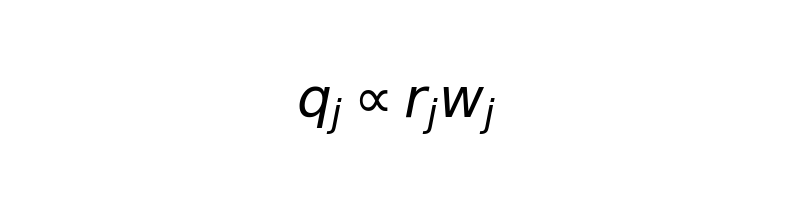</p>


로 놓는다. $r_j$는 presynaptic firing rate, $w_j$는 excitatory weight이다.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('fig3_notebook_outputs')
OUT.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

EPS = 1e-12



## 1. Fig. 3에서 쓰는 핵심 변수

논문에서 excitatory plasticity는 synapse 하나의 spike timing만 보는 것이 아니라, 주변 synapse들의 NMDA current history까지 본다.


<p align="center">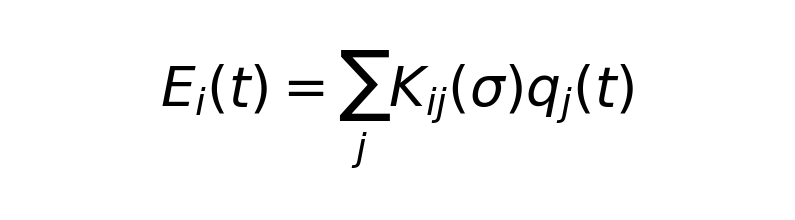</p>


- $i$: plasticity가 일어나는 synapse
- $j$: 주변 synapse
- $q_j$: synapse $j$가 만든 NMDA current
- $K_{ij}(\sigma)$: synapse $j$가 synapse $i$의 plasticity에 영향을 주는 정도
- $\sigma$: distance interaction의 길이 상수

논문 Fig. 3b에서는 synapse들이 1D line 위에 있고, 바로 옆 synapse와의 거리가 $\Delta x=1$이라고 둔다. Gaussian coupling은 다음과 같이 쓴다.


<p align="center">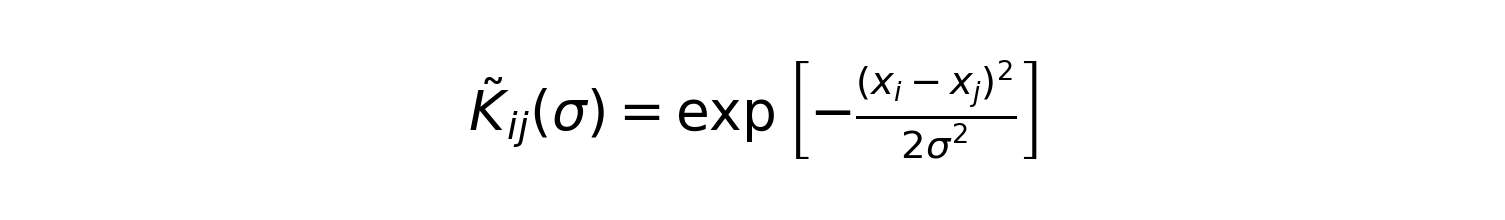</p>


서로 다른 $\sigma$를 공정하게 비교하려고 row sum이 1이 되게 normalize한다.


<p align="center">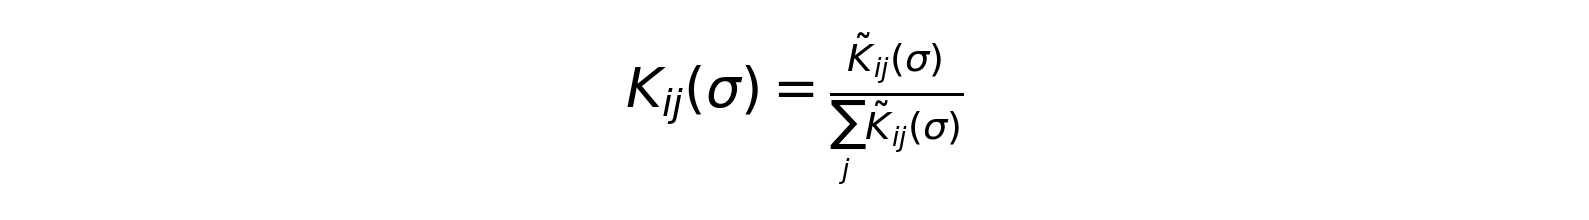</p>



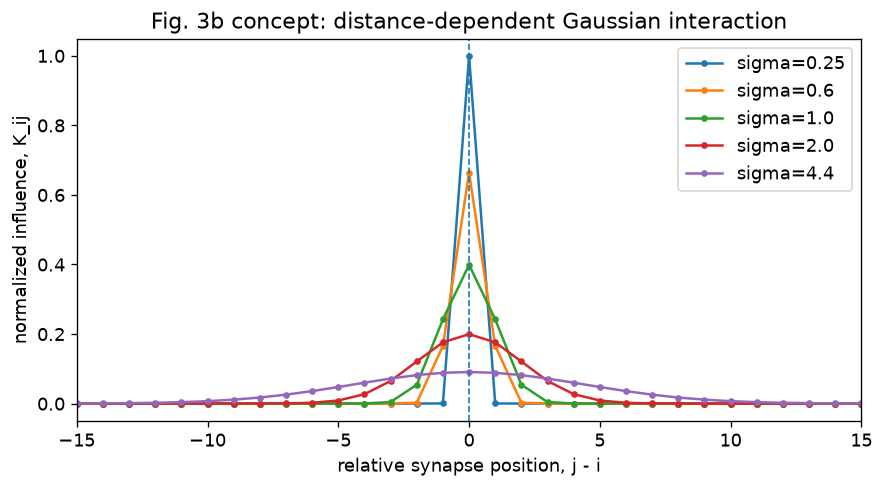

In [2]:

def gaussian_kernel(n_syn=101, sigma=1.0):
    """Row-normalized distance interaction kernel K_ij(sigma)."""
    if sigma <= 1e-9:
        return np.eye(n_syn)
    x = np.arange(n_syn)
    d = x[:, None] - x[None, :]
    K = np.exp(-(d ** 2) / (2.0 * sigma ** 2))
    K /= K.sum(axis=1, keepdims=True)
    return K

# 중앙 synapse가 주변 synapse들로부터 받는 influence profile을 그림으로 확인
n_syn = 101
center = n_syn // 2
sigmas_to_show = [0.25, 0.6, 1.0, 2.0, 4.4]

plt.figure(figsize=(7.5, 4.2))
for sigma in sigmas_to_show:
    K = gaussian_kernel(n_syn, sigma)
    x_rel = np.arange(n_syn) - center
    plt.plot(x_rel, K[center], marker='o', markersize=3, label=f'sigma={sigma}')

plt.axvline(0, linestyle='--', linewidth=1)
plt.xlim(-15, 15)
plt.xlabel('relative synapse position, j - i')
plt.ylabel('normalized influence, K_ij')
plt.title('Fig. 3b concept: distance-dependent Gaussian interaction')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / '01_distance_kernel.png', dpi=200)
plt.show()



## 2. Excitatory plasticity가 setpoint를 만드는 이유

논문 수식을 발표용으로 단순화하면 excitatory weight change는 다음 구조다.


<p align="center">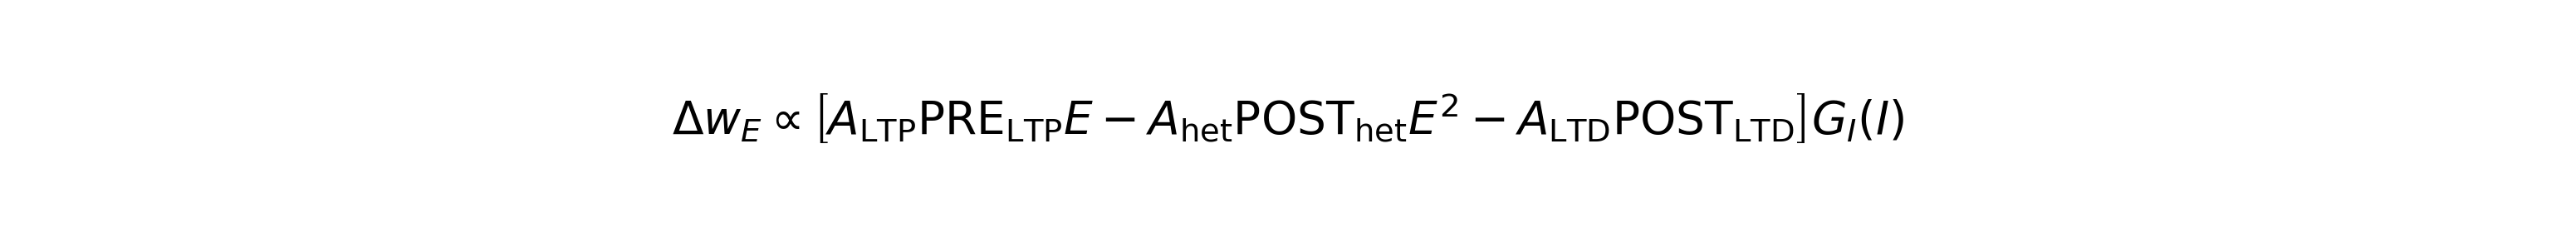</p>


Fig. 3에서는 핵심이 excitatory current stability이므로, 먼저 inhibition gate와 LTD를 잠시 고정하거나 생략하고,
pre-before-post 상황의 LTP와 heterosynaptic weakening만 본다.


<p align="center">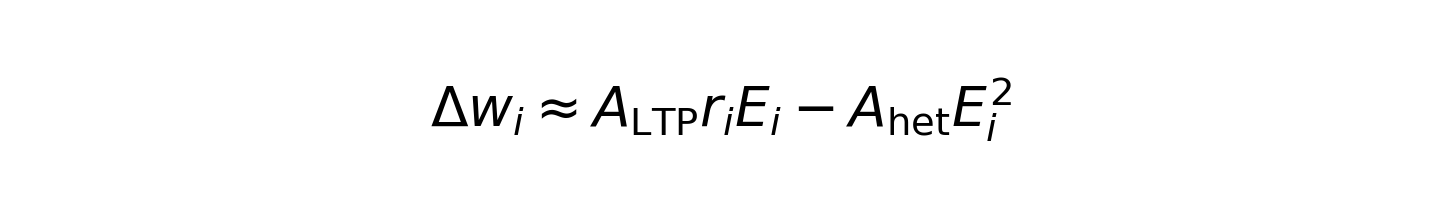</p>


여기서 $r_i$는 presynaptic activity가 만든 평균 pre trace라고 보면 된다.
따라서


<p align="center">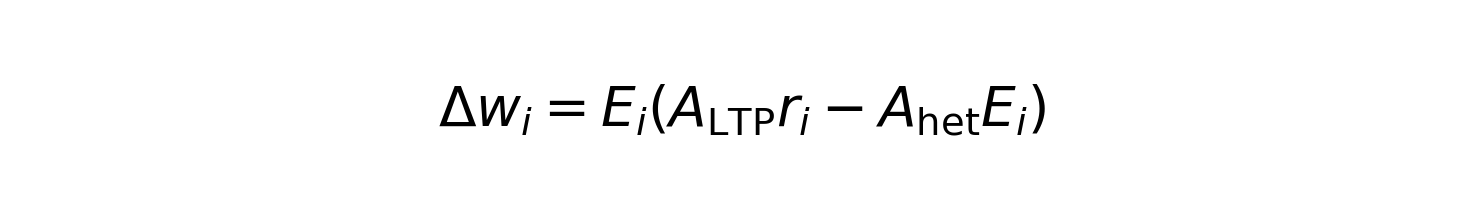</p>


이고 fixed point는


<p align="center">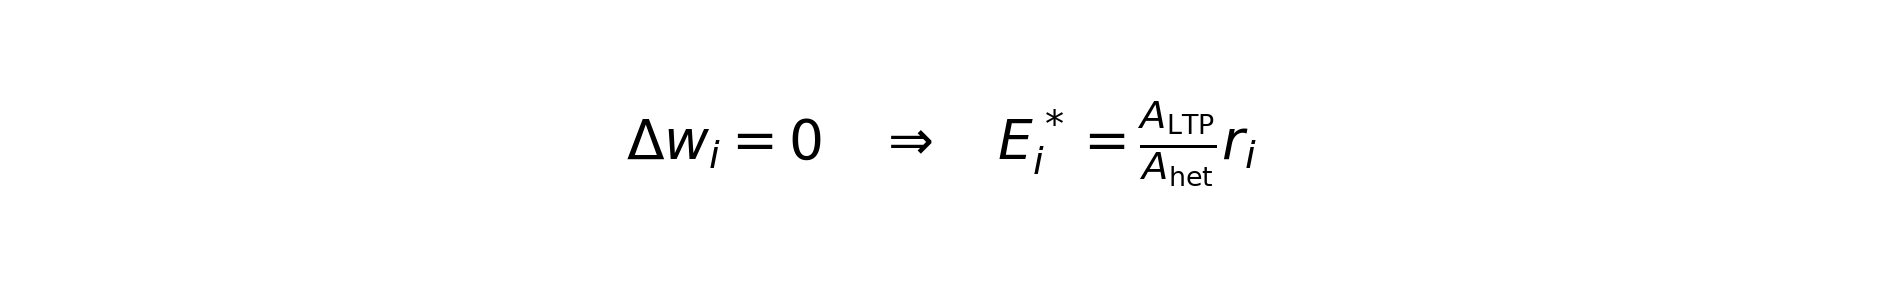</p>


이다. 즉, $E_i$가 너무 작으면 LTP가 이기고, $E_i$가 너무 크면 heterosynaptic weakening이 이긴다.


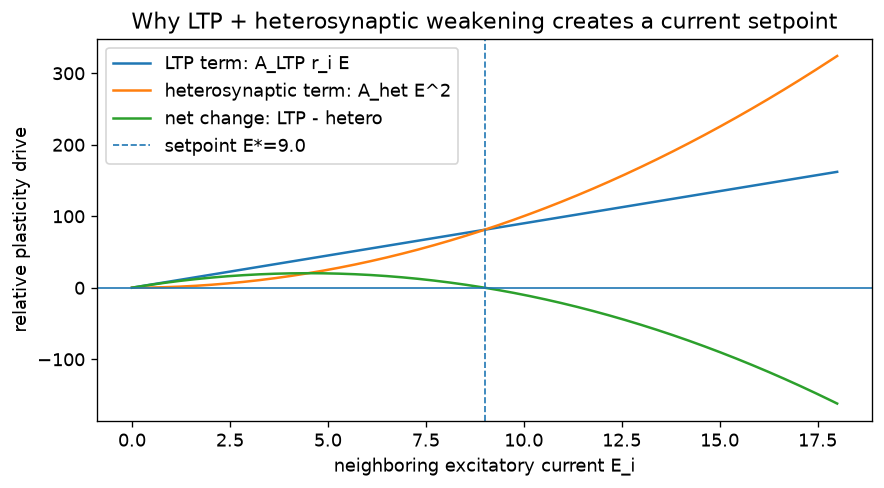

In [3]:

# LTP - heterosynaptic weakening balance plot
A_ltp = 1.0
A_het = 1.0
r_i = 9.0
E = np.linspace(0, 18, 400)
ltp = A_ltp * r_i * E
het = A_het * E ** 2
net = ltp - het
E_star = A_ltp * r_i / A_het

plt.figure(figsize=(7.5, 4.2))
plt.plot(E, ltp, label='LTP term: A_LTP r_i E')
plt.plot(E, het, label='heterosynaptic term: A_het E^2')
plt.plot(E, net, label='net change: LTP - hetero')
plt.axhline(0, linewidth=1)
plt.axvline(E_star, linestyle='--', linewidth=1, label=f'setpoint E*={E_star:.1f}')
plt.xlabel('neighboring excitatory current E_i')
plt.ylabel('relative plasticity drive')
plt.title('Why LTP + heterosynaptic weakening creates a current setpoint')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / '02_setpoint_from_ltp_hetero.png', dpi=200)
plt.show()



## 3. 거리 coupling을 넣으면 $E_i$가 어떻게 바뀌는가

synapse-specific NMDA current를


<p align="center">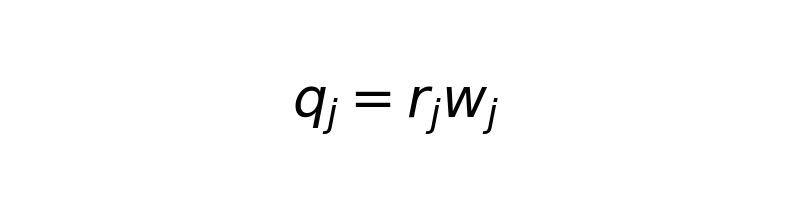</p>


라고 두면, plasticity가 실제로 보는 neighboring current는


<p align="center">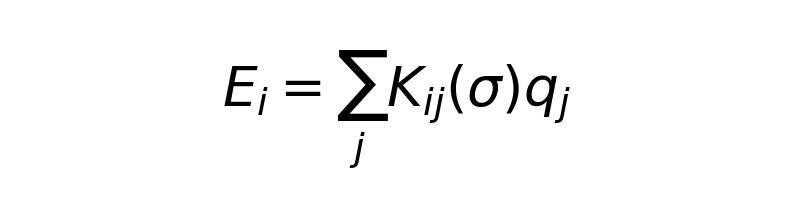</p>


이다.

- $\sigma \rightarrow 0$: $K_{ij}$가 거의 identity matrix라서 $E_i \approx q_i$. 즉, synapse가 거의 자기 자신만 본다.
- $\sigma$가 커짐: $E_i$가 주변 synapse들의 평균 current가 된다. 즉, 한 synapse의 변화가 주변 synapse의 plasticity에 영향을 준다.

아래 toy equilibrium은 발표용 직관을 위한 것이다. 실제 논문 full simulation과 정확히 같은 parameter fitting은 아니다.


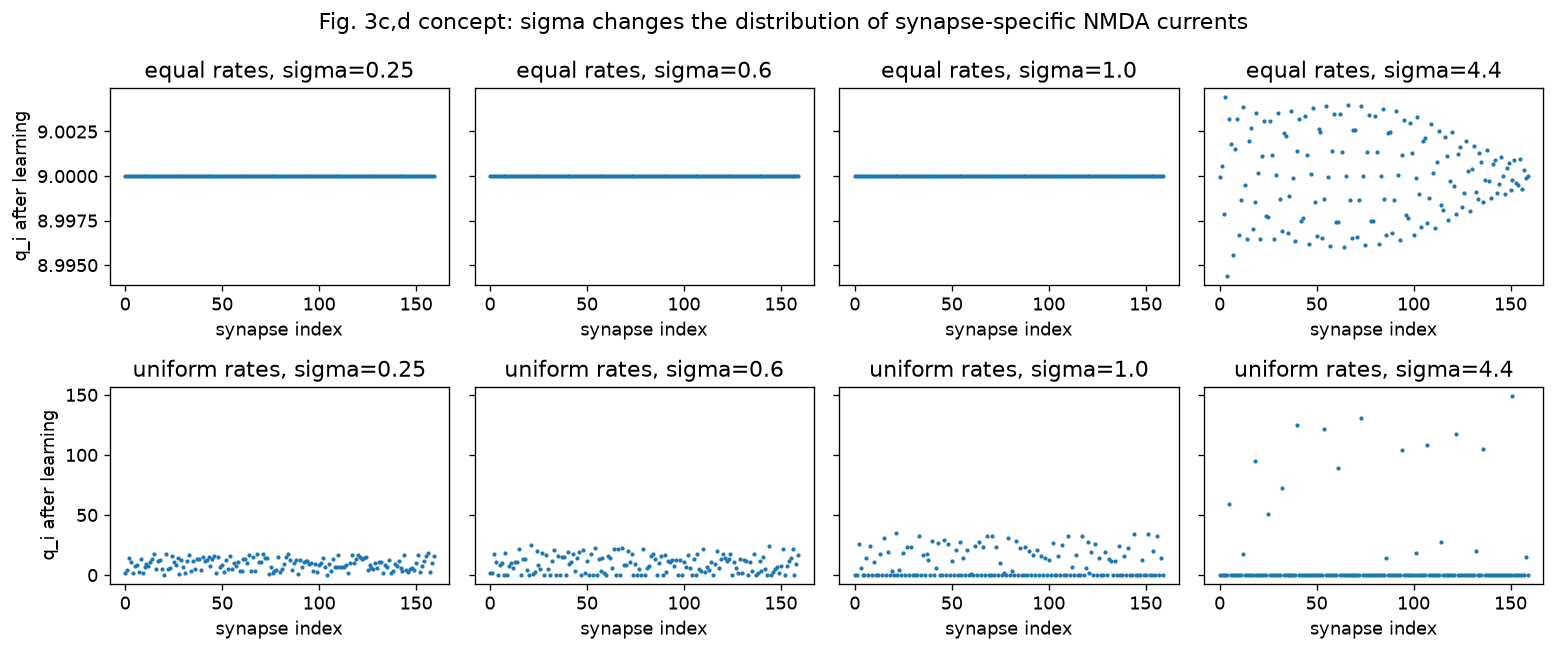

In [4]:

def nonnegative_equilibrium_currents(rates, sigma, beta=1.0, target_mean=9.0, max_iter=20):
    """
    Approximate active-set solution for K q ~= rates / beta with q >= 0.

    Interpretation:
    - q_j = synapse-specific NMDA current produced by synapse j
    - E_i = sum_j K_ij q_j
    - simplified fixed point for an active synapse: E_i ~= rates_i / beta

    After solving, q is rescaled so that the average current is held at
    the same global setpoint. This isolates the main Fig. 3 idea:
    sigma changes the distribution/variance more than the mean setpoint.
    """
    rates = np.asarray(rates, dtype=float)
    n = len(rates)
    K = gaussian_kernel(n, sigma)
    target = rates / beta
    active = np.ones(n, dtype=bool)
    q = np.zeros(n)

    for _ in range(max_iter):
        A = K[np.ix_(active, active)]
        b = target[active]
        if A.size == 0:
            break
        sol = np.linalg.lstsq(A, b, rcond=None)[0]
        q_new = np.zeros(n)
        q_new[active] = sol
        bad = (q_new < 0) & active
        q = np.maximum(q_new, 0.0)
        if not np.any(bad):
            break
        active[bad] = False

    # Global current setpoint normalization for the pedagogical plot.
    if q.mean() > 0:
        q = q * (target_mean / q.mean())
    E = K @ q
    w = q / np.maximum(rates, EPS)
    return q, E, w, active

# 예시: firing rate가 균일한 경우 vs 0~18 Hz로 흩어진 경우
rng = np.random.default_rng(3)
n = 160
rates_equal = np.ones(n) * 9.0
rates_uniform = rng.uniform(0.0, 18.0, size=n)

sigma_examples = [0.25, 0.6, 1.0, 4.4]
fig, axes = plt.subplots(2, len(sigma_examples), figsize=(13, 5.5), sharey='row')

for col, sigma in enumerate(sigma_examples):
    q_eq, E_eq, w_eq, active_eq = nonnegative_equilibrium_currents(rates_equal, sigma)
    q_un, E_un, w_un, active_un = nonnegative_equilibrium_currents(rates_uniform, sigma)

    axes[0, col].plot(q_eq, marker='.', linestyle='none', markersize=3)
    axes[0, col].set_title(f'equal rates, sigma={sigma}')
    axes[0, col].set_xlabel('synapse index')

    axes[1, col].plot(q_un, marker='.', linestyle='none', markersize=3)
    axes[1, col].set_title(f'uniform rates, sigma={sigma}')
    axes[1, col].set_xlabel('synapse index')

axes[0, 0].set_ylabel('q_i after learning')
axes[1, 0].set_ylabel('q_i after learning')
plt.suptitle('Fig. 3c,d concept: sigma changes the distribution of synapse-specific NMDA currents')
plt.tight_layout()
plt.savefig(OUT / '03_current_distributions_by_sigma.png', dpi=200)
plt.show()


In [5]:

# sigma sweep: mean and standard deviation of current after learning
sigmas = np.concatenate([
    np.linspace(0.05, 1.0, 16),
    np.linspace(1.2, 8.0, 20)
])

rows = []
for sigma in sigmas:
    for label, rates in [('equal 9 Hz', rates_equal), ('uniform 0-18 Hz', rates_uniform)]:
        q, Ecur, w, active = nonnegative_equilibrium_currents(rates, sigma)
        rows.append({
            'sigma': sigma,
            'rate_condition': label,
            'mean_q': q.mean(),
            'std_q': q.std(),
            'mean_E': Ecur.mean(),
            'std_E': Ecur.std(),
            'deleted_fraction': 1.0 - active.mean(),
        })

df_sigma = pd.DataFrame(rows)
df_sigma.head()


,sigma,rate_condition,mean_q,std_q,mean_E,std_E,deleted_fraction
0,0.050000,equal 9 Hz,9.0,0.000000e+00,9.0,0.000000e+00,0.0
1,0.050000,uniform 0-18 Hz,9.0,4.841953e+00,9.0,4.841953e+00,0.0
2,0.113333,equal 9 Hz,9.0,4.333000e-15,9.0,4.333000e-15,0.0
3,0.113333,uniform 0-18 Hz,9.0,4.841953e+00,9.0,4.841953e+00,0.0
4,0.176667,equal 9 Hz,9.0,1.448575e-14,9.0,1.448575e-14,0.0


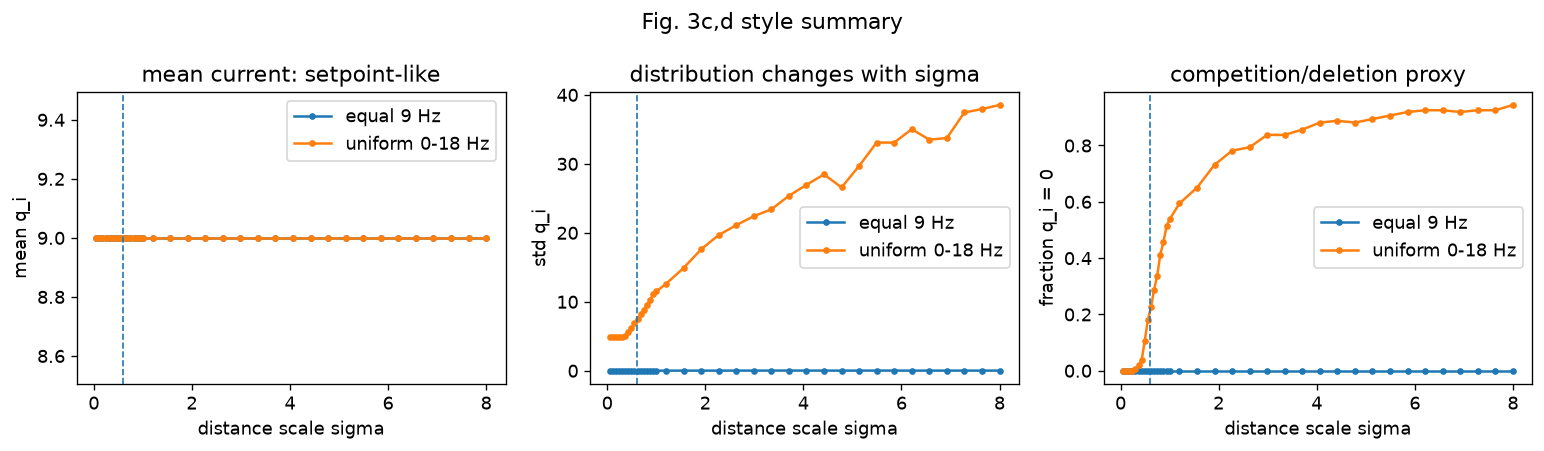

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for label, g in df_sigma.groupby('rate_condition'):
    axes[0].plot(g['sigma'], g['mean_q'], marker='o', markersize=3, label=label)
    axes[1].plot(g['sigma'], g['std_q'], marker='o', markersize=3, label=label)
    axes[2].plot(g['sigma'], g['deleted_fraction'], marker='o', markersize=3, label=label)

for ax in axes:
    ax.axvline(0.6, linestyle='--', linewidth=1)
    ax.set_xlabel('distance scale sigma')
    ax.legend()

axes[0].set_ylabel('mean q_i')
axes[0].set_title('mean current: setpoint-like')
axes[1].set_ylabel('std q_i')
axes[1].set_title('distribution changes with sigma')
axes[2].set_ylabel('fraction q_i = 0')
axes[2].set_title('competition/deletion proxy')

plt.suptitle('Fig. 3c,d style summary')
plt.tight_layout()
plt.savefig(OUT / '04_sigma_sweep_summary.png', dpi=200)
plt.show()



## 4. $\sigma_{th}$를 직관적으로 보기

논문은 $\sigma_{th}\approx 0.6$ 근처를 “effectively non-interacting synapses”에서 “interacting synapses”로 넘어가는 전환점으로 설명한다.

이 toy view에서는 중앙 synapse가 자기 자신에게 주는 영향과 주변 synapse들이 주는 영향을 나누어 본다.


<p align="center">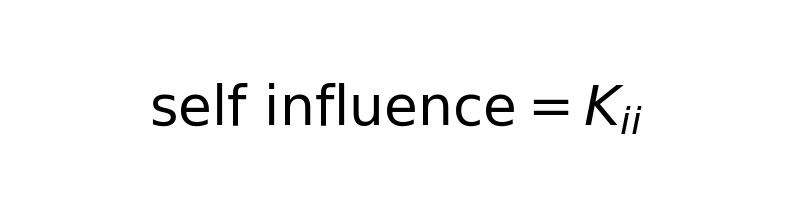</p>



<p align="center">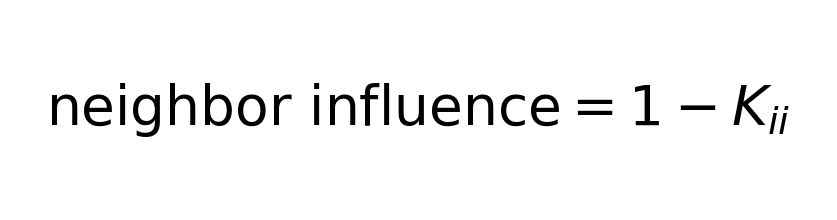</p>


$\sigma$가 작으면 거의 자기 자신만 보고, $\sigma$가 커지면 주변 synapse들의 영향이 커진다.


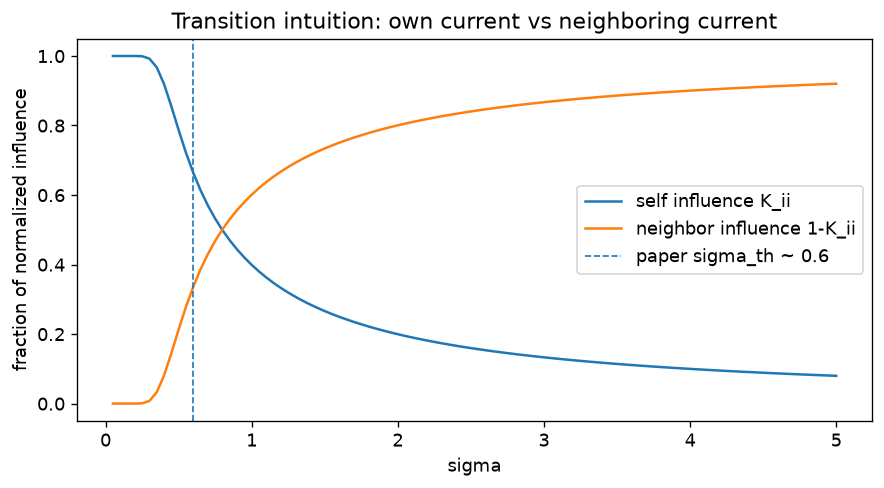

In [7]:

sigma_grid = np.linspace(0.05, 5.0, 100)
self_inf = []
neigh_inf = []
for sigma in sigma_grid:
    K = gaussian_kernel(401, sigma)
    c = 401 // 2
    self_inf.append(K[c, c])
    neigh_inf.append(1.0 - K[c, c])
self_inf = np.array(self_inf)
neigh_inf = np.array(neigh_inf)

plt.figure(figsize=(7.5, 4.2))
plt.plot(sigma_grid, self_inf, label='self influence K_ii')
plt.plot(sigma_grid, neigh_inf, label='neighbor influence 1-K_ii')
plt.axvline(0.6, linestyle='--', linewidth=1, label='paper sigma_th ~ 0.6')
plt.xlabel('sigma')
plt.ylabel('fraction of normalized influence')
plt.title('Transition intuition: own current vs neighboring current')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / '05_sigma_threshold_intuition.png', dpi=200)
plt.show()



## 5. Fig. 3e--g: total NMDA current setpoint의 analytic intuition

Fig. 3e--g의 요지는 total NMDA current의 안정점이 주로 plasticity learning-rate ratio로 정해지고, 초기 excitatory weight에는 거의 의존하지 않는다는 점이다.

단순화된 식에서 fixed point는


<p align="center">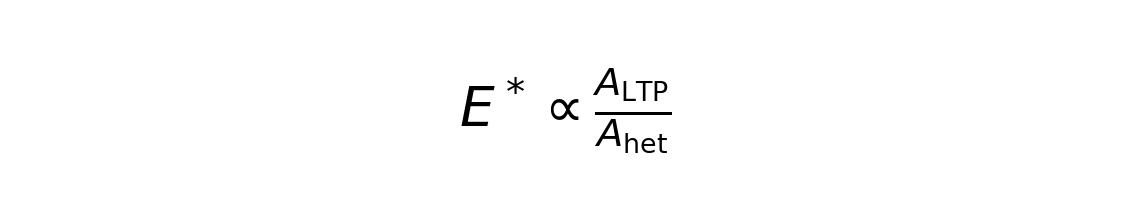</p>


이므로 heterosynaptic weakening이 강해질수록 안정적인 total NMDA current는 낮아진다.

아래 plot은 정확한 논문 fitting이 아니라 발표용 직관 plot이다.


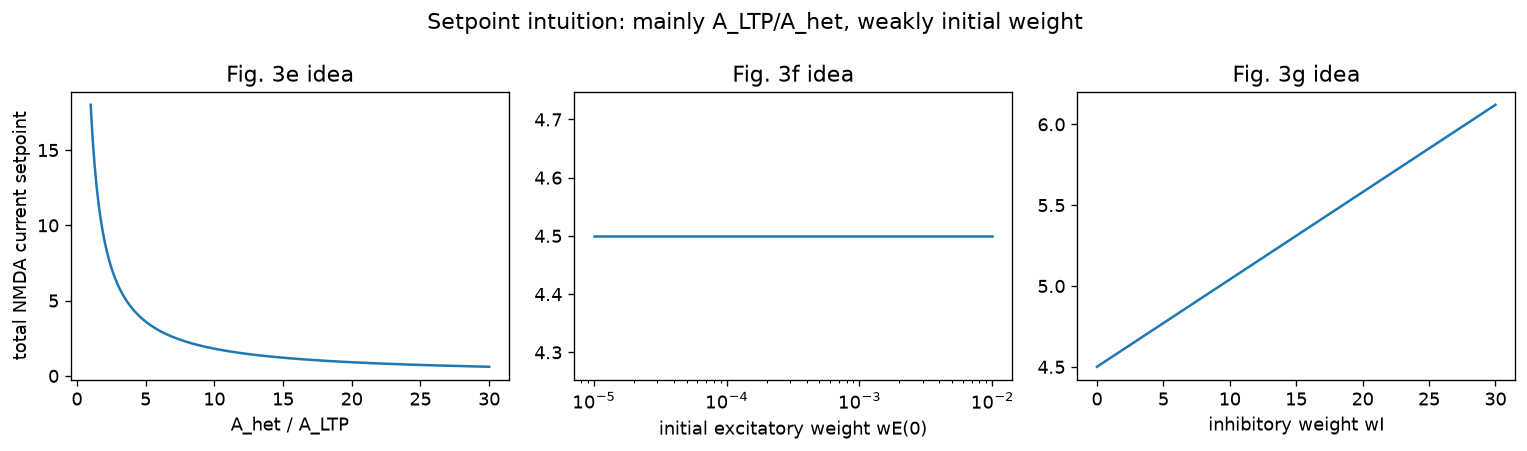

In [8]:

# Conceptual analytic curves for Fig. 3e-g
C = 18.0
ratio = np.linspace(1.0, 30.0, 200)  # A_het / A_LTP
T_vs_ratio = C / ratio

wE0 = np.logspace(-5, -2, 120)
T_vs_wE0 = np.ones_like(wE0) * (C / 4.0)

wI = np.linspace(0.0, 30.0, 150)
T_vs_wI = (C / 4.0) * (1.0 + 0.012 * wI)  # weak dependence proxy

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(ratio, T_vs_ratio)
axes[0].set_xlabel('A_het / A_LTP')
axes[0].set_ylabel('total NMDA current setpoint')
axes[0].set_title('Fig. 3e idea')

axes[1].plot(wE0, T_vs_wE0)
axes[1].set_xscale('log')
axes[1].set_xlabel('initial excitatory weight wE(0)')
axes[1].set_title('Fig. 3f idea')

axes[2].plot(wI, T_vs_wI)
axes[2].set_xlabel('inhibitory weight wI')
axes[2].set_title('Fig. 3g idea')

plt.suptitle('Setpoint intuition: mainly A_LTP/A_het, weakly initial weight')
plt.tight_layout()
plt.savefig(OUT / '06_setpoint_parameter_intuition.png', dpi=200)
plt.show()



## 6. 요약 문장

1. **거리 coupling 정의**  
   $E_i=\sum_j K_{ij}(\sigma)q_j$. $\sigma$가 작으면 synapse-specific, $\sigma$가 크면 neighboring synapses까지 포함한다.

2. **왜 안정한가**  
   LTP는 $E$에 선형으로 증가하고, heterosynaptic weakening은 $E^2$에 비례해서 증가한다. 그래서 $E$가 작을 때는 강화, 너무 클 때는 약화가 되어 current setpoint가 생긴다.

3. **$\sigma$의 역할**  
   평균 current setpoint는 크게 변하지 않지만, synapse-specific current와 weight의 **분포**는 바뀐다. $\sigma$가 커지면 서로 경쟁하게 되어 낮은-rate synapse가 불리해질 수 있다.

4. **Fig. 3e--g**  
   Total NMDA current setpoint는 주로 $A_{\mathrm{het}}/A_{\mathrm{LTP}}$로 정해진다. 초기 excitatory weight에는 약하게 의존하거나 거의 의존하지 않고, inhibitory weight에는 postsynaptic firing state를 통해 약하게 영향을 받는다.

> “이 노트북은 Fig. 3의 full-scale simulation reproduction이 아니라, Fig. 3의 수식 구조와 안정화 원리를 plotting으로 이해하기 위한 derivation-first toy implementation입니다.”
